In [1]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
#Import numpy
import numpy as np

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

d:\Deep Learning\Lab Activities\tfenv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


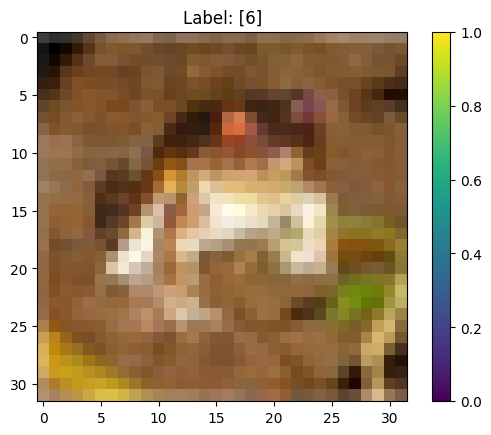

In [3]:
#Visualize the data
plt.figure()

plt.imshow(train_images[0]) # Display the first image in the plot area

plt.colorbar()

plt.title(f"Label: {train_labels[0]}") # Displays the label of the first image

plt.grid(False)

plt.show() # Render and displaysthe plot window.

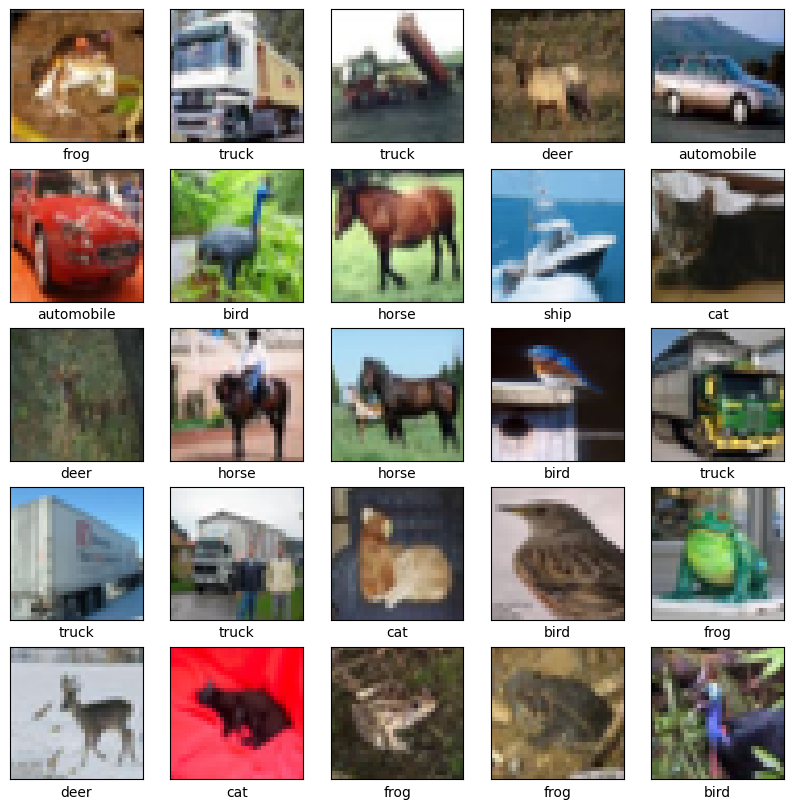

In [4]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays, 
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [5]:
#Build the Neural Network Model. 
model = models.Sequential()
model.add(layers.Input(shape=(32,32,3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Add Dense layers on top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Compile the Model.  
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [8]:
#Train the Model. 
history = model.fit(train_images, train_labels, epochs=10, 
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.4440 - loss: 1.5247 - val_accuracy: 0.5414 - val_loss: 1.2645
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.5845 - loss: 1.1658 - val_accuracy: 0.5881 - val_loss: 1.1685
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6432 - loss: 1.0155 - val_accuracy: 0.6503 - val_loss: 1.0052
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6769 - loss: 0.9198 - val_accuracy: 0.6728 - val_loss: 0.9442
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.7048 - loss: 0.8469 - val_accuracy: 0.6812 - val_loss: 0.9276
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.7240 - loss: 0.7879 - val_accuracy: 0.6846 - val_loss: 0.9098
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7452 - loss: 0.7324 - val_accuracy: 0.6970 - val_loss: 0.8735
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7598 -

313/313 - 2s - 6ms/step - accuracy: 0.7039 - loss: 0.8858
Test Accuracy:  70.38999795913696 %
Test Loss:  0.8857533931732178


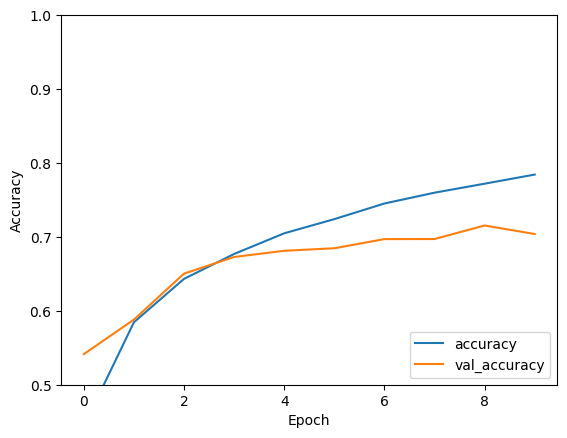

In [9]:
#Evaluate the Model
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print( "Test Accuracy: " , test_acc * 100, "%")
print( "Test Loss: " , test_loss)

In [12]:
# Make predictions

probability_model = models.Sequential([
    model,                         # The trained model (outputs logits/raw scores)
    layers.Softmax()       # Convert raw scores into probabilities
])

predictions = probability_model.predict(test_images)  # Predict probabilities for test images

print(predictions)
predicted_value=np.argmax(predictions[1])
print(predicted_value)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
[[2.2341479e-03 2.6226954e-03 8.1664575e-03 ... 8.9906121e-04
  1.0466818e-02 1.7087864e-03]
 [1.8929321e-02 5.3606695e-01 1.1315114e-07 ... 4.1560497e-08
  4.3911603e-01 5.8874674e-03]
 [6.3145876e-02 5.5483228e-01 1.3264874e-02 ... 4.6369685e-03
  2.5079757e-01 9.8073706e-02]
 ...
 [1.4031432e-06 1.6836876e-07 2.3698578e-02 ... 1.8897183e-02
  3.8252065e-07 2.0058454e-07]
 [2.7600257e-04 4.3073538e-01 4.5063251e-05 ... 3.4555705e-05
  2.9515897e-06 8.3706482e-07]
 [3.9966403e-06 2.5232378e-06 4.6033727e-04 ... 9.5969987e-01
  8.9321463e-07 6.7553933e-06]]
1


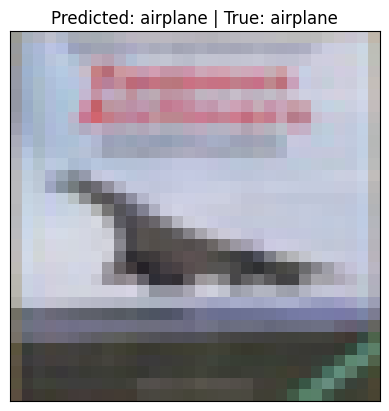

Predicted Label: airplane
True Label: airplane


In [11]:
# Display a predicted image with its predicted and true label

index = predicted_value   # You can change this to test other images

plt.figure()
plt.imshow(test_images[index])
plt.xticks([])
plt.yticks([])
plt.grid(False)

predicted_label = class_names[np.argmax(predictions[index])]
true_label = class_names[test_labels[index][0]]

plt.title("Predicted: " + predicted_label + " | True: " + true_label)
plt.show()

print("Predicted Label:", predicted_label)
print("True Label:", true_label)